In [2]:
%matplotlib inline

In [3]:
import xtrack as xt
import xpart as xp
import matplotlib.pyplot as plt

In [4]:
p0_carbon = xt.Particles('Carbon-12', q0=6)
p0_helium = xt.Particles('Helium-4', q0=2)

In [5]:
p0_carbon.pdg_id, p0_helium.pdg_id

(array([1000060120]), array([1000020040]))

In [6]:
mass_ratio_he_ca = p0_helium.mass0 / p0_carbon.mass0
charge_ratio_he_ca = p0_helium.q0 / p0_carbon.q0

In [7]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')

line = env.ring
line.configure_bend_model(core='bend-kick-bend')#num_multipole_kicks=5)
line.set_particle_ref('proton', kinetic_energy0=100e6)

tw4d = line.twiss4d()
eta = tw4d.slip_factor
line_length = tw4d.line_length

line['vrf'] = 10e3            # V
line['frf'] = 1 / tw4d.t_rev0 # h=1

env['dp'] = 0
line.append(
    env.new('tdelay', xt.TimeDelay, shift_zeta=-eta * line_length * env.ref['dp']))

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [10]:
env['dp'] = -2.4e-3
tw_carbon = line.twiss6d()
tw_helium = line.twiss6d(mass_ratio=mass_ratio_he_ca, charge_ratio=charge_ratio_he_ca)

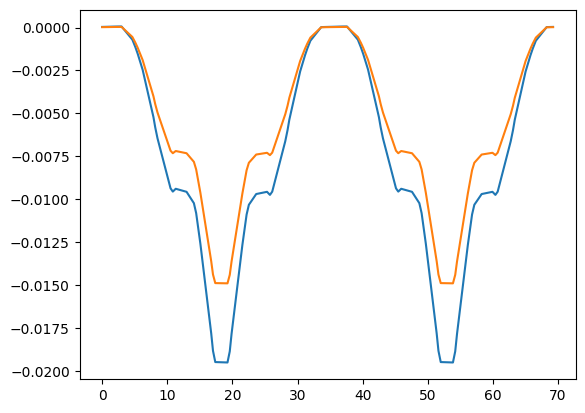

In [11]:
plt.plot(tw_carbon.s, tw_carbon.x)
plt.plot(tw_carbon.s, tw_helium.x)

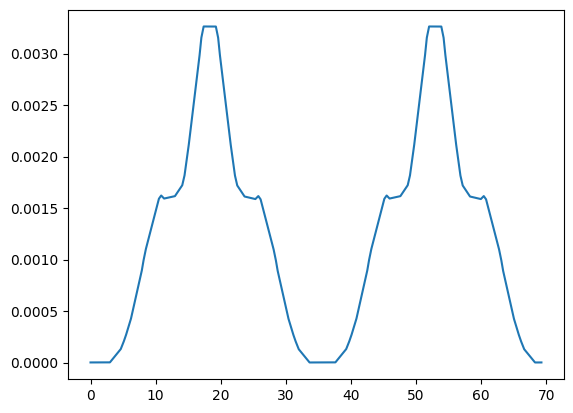

In [12]:
plt.plot(tw_helium.s, tw_helium.x)

In [13]:
tw_helium.zeta

array([ 4.78278940e-39, -3.81916720e-14, -3.81916720e-14, -7.63833441e-14,
       -8.44990744e-14, -9.03555009e-14, -9.12873666e-14,  1.08218646e-04,
        1.08212597e-04,  1.08206697e-04,  1.08190373e-04, -2.00724286e-05,
       -2.00910526e-05, -2.01077844e-05, -2.01346191e-05, -2.01583317e-05,
       -2.01642751e-05, -2.01672451e-05, -2.01700488e-05, -2.01710095e-05,
       -5.23657560e-04, -5.23662551e-04, -5.23677637e-04, -5.23745670e-04,
       -1.40376738e-03, -1.40381969e-03, -1.40384210e-03, -1.40384210e-03,
       -1.40384210e-03, -1.40384210e-03, -1.40384210e-03, -1.40386457e-03,
       -1.40391697e-03, -2.28334157e-03, -2.28340977e-03, -2.28342493e-03,
       -2.28342584e-03, -2.28342674e-03, -2.28343001e-03, -2.78520243e-03,
       -2.78520337e-03, -2.78520617e-03, -2.78523872e-03, -2.78526548e-03,
       -2.78528214e-03, -2.78530067e-03, -2.91211220e-03, -2.91212838e-03,
       -2.91213424e-03, -2.91214025e-03, -2.80335846e-03, -2.80335846e-03,
       -2.80335846e-03, -

In [14]:
tw_carbon.zeta

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00012508, 0.00012508, 0.00012508,
       0.00012508, 0.00023559, 0.00023559, 0.00023559, 0.00023559,
       0.00023559, 0.00023559, 0.00023559, 0.00023559, 0.00023559,
       0.00032294, 0.00032294, 0.00032294, 0.00032294, 0.00038703,
       0.00038703, 0.00038703, 0.00038703, 0.00038703, 0.00038703,
       0.00038703, 0.00038703, 0.00038703, 0.00045113, 0.00045113,
       0.00045113, 0.00045113, 0.00045113, 0.00045113, 0.00053848,
       0.00053848, 0.00053848, 0.00053848, 0.00053848, 0.00053848,
       0.00053848, 0.000649  , 0.000649  , 0.000649  , 0.000649  ,
       0.00077408, 0.00077408, 0.00077408, 0.00077408, 0.00077408,
       0.00077408, 0.00077408, 0.00077408, 0.00077408, 0.00077408,
       0.00077408, 0.00089916, 0.00089916, 0.00089916, 0.00089916,
       0.00100967, 0.00100967, 0.00100967, 0.00100967, 0.00100967,
       0.00100967, 0.00100967, 0.00100967, 0.00100967, 0.00109